In [1]:
from transformer_lens import HookedTransformer
import torch

model = HookedTransformer.from_pretrained("gpt2")
model.eval()

prompt = "The capital of France is"
logits, cache = model.run_with_cache(prompt)

for key in cache.keys():
    print(key)

/home/baskar/Desktop/mi-probe-suite/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
hook_embed
hook_pos_embed
blocks.0.hook_resid_pre
blocks.0.ln1.hook_scale
blocks.0.ln1.hook_normalized
blocks.0.attn.hook_q
blocks.0.attn.hook_k
blocks.0.attn.hook_v
blocks.0.attn.hook_attn_scores
blocks.0.attn.hook_pattern
blocks.0.attn.hook_z
blocks.0.hook_attn_out
blocks.0.hook_resid_mid
blocks.0.ln2.hook_scale
blocks.0.ln2.hook_normalized
blocks.0.mlp.hook_pre
blocks.0.mlp.hook_post
blocks.0.hook_mlp_out
blocks.0.hook_resid_post
blocks.1.hook_resid_pre
blocks.1.ln1.hook_scale
blocks.1.ln1.hook_normalized
blocks.1.attn.hook_q
blocks.1.attn.hook_k
blocks.1.attn.hook_v
blocks.1.attn.hook_attn_scores
blocks.1.attn.hook_pattern
blocks.1.attn.hook_z
blocks.1.hook_attn_out
blocks.1.hook_resid_mid
blocks.1.ln2.hook_scale
blocks.1.ln2.hook_normalized
blocks.1.mlp.hook_pre
blocks.1.mlp.hook_post
blocks.1.hook_mlp_out
blocks.1.hook_resid_post
blocks.2.hook_resid_pre
blocks.2.ln1.hook_scale
blocks.2.ln1.hook_normalized
blocks.2.attn.hook_q
bl

In [2]:
import matplotlib.pyplot as plt
import numpy as np

prompt = "The capital of France is"
logits, cache = model.run_with_cache(prompt)

tokens = model.to_str_tokens(prompt)
print("Tokens:", tokens)

# Pick token position 3 = "France"
token_pos = 3

layer_activations = []
for layer in range(model.cfg.n_layers):
    resid = cache[f"blocks.{layer}.hook_resid_post"]
    activation = resid[0, token_pos, :].detach().numpy()
    layer_activations.append(activation)

layer_activations = np.array(layer_activations)
print("Shape:", layer_activations.shape)  # (12, 768)

Tokens: ['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is']
Shape: (12, 768)


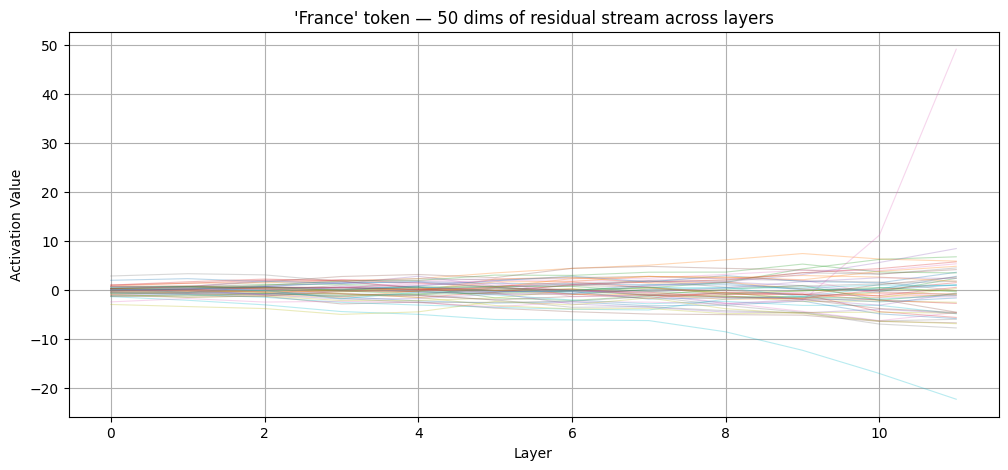

In [3]:
# Plot first 50 dimensions across layers
plt.figure(figsize=(12, 5))
for dim in range(50):
    plt.plot(range(model.cfg.n_layers), 
             layer_activations[:, dim], 
             alpha=0.3, linewidth=0.8)

plt.xlabel("Layer")
plt.ylabel("Activation Value")
plt.title("'France' token — 50 dims of residual stream across layers")
plt.grid(True)
plt.savefig("../results/session2_residual_evolution.png")
plt.show()

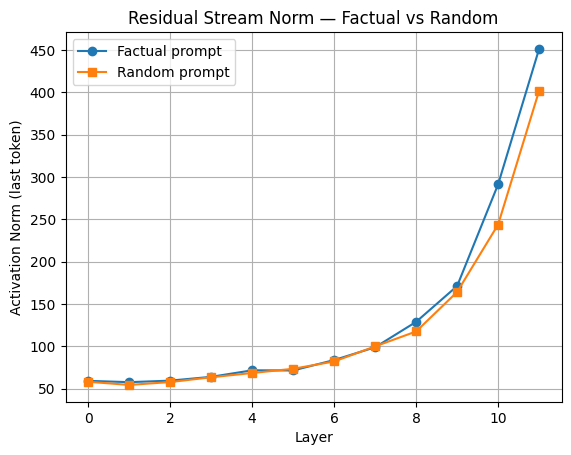

In [4]:
prompt_factual = "The capital of France is"
prompt_random = "I really enjoy eating pizza on"

_, cache_factual = model.run_with_cache(prompt_factual)
_, cache_random = model.run_with_cache(prompt_random)

factual_norms = []
random_norms = []

for layer in range(model.cfg.n_layers):
    f = cache_factual[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    r = cache_random[f"blocks.{layer}.hook_resid_post"][0, -1, :]
    factual_norms.append(f.norm().item())
    random_norms.append(r.norm().item())

plt.plot(factual_norms, marker='o', label="Factual prompt")
plt.plot(random_norms, marker='s', label="Random prompt")
plt.xlabel("Layer")
plt.ylabel("Activation Norm (last token)")
plt.title("Residual Stream Norm — Factual vs Random")
plt.legend()
plt.grid(True)
plt.savefig("../results/session2_factual_vs_random.png")
plt.show()

In [6]:
import sys
sys.path.append("../")
from src.data.activation_extractor import extract_residual_stream, extract_batch

activations = extract_residual_stream(model, "The capital of France is")
print("Shape:", activations.shape)  # (12, 768)

Shape: (12, 768)


In [7]:
prompts = [
    "The capital of France is",
    "The president of the USA is",
    "Water boils at a temperature of",
    "The speed of light is approximately",
]

batch_activations = extract_batch(model, prompts)
print("Batch shape:", batch_activations.shape)  # (4, 12, 768)

Batch shape: (4, 12, 768)


In [8]:
# Layer 6, prompt 0, first 5 dims
print(batch_activations[0, 6, :5])

# Should match direct extraction
direct = extract_residual_stream(model, prompts[0])
print(direct[6, :5])

# These must be identical
assert np.allclose(batch_activations[0], direct), "Mismatch!"
print("Sanity check passed ✅")

[-2.202228    0.39931574 -2.0359035   1.0987893   0.9734409 ]
[-2.202228    0.39931574 -2.0359035   1.0987893   0.9734409 ]
Sanity check passed ✅
